In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [2]:
#Load the dataset
data = pd.read_csv("/content/Employee_Segmentation_Dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
data.head()

,Employee_ID,Age,Department,Years_of_Experience,Annual_Salary,Job_Satisfaction_Score,Performance_Rating,Training_Hours_Year,Projects_Completed,Absence_Days_Year,Remote_Work,Employee_Profile
0,1071,41,Sales,11,57321,2.0,2.4,27,7,3,No,General_Employee
1,1828,32,Sales,10,51606,1.3,1.5,19,7,7,Yes,General_Employee
2,1232,42,IT,20,102190,4.8,3.2,0,4,12,No,Higher_Salary
3,1589,45,HR,23,71178,3.8,4.8,40,7,5,No,High_Performance
4,1040,52,HR,28,77618,2.4,3.4,25,5,10,No,General_Employee


In [4]:
data.describe()

,Employee_ID,Age,Years_of_Experience,Annual_Salary,Job_Satisfaction_Score,Performance_Rating,Training_Hours_Year,Projects_Completed,Absence_Days_Year
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1450.500000,41.028889,16.033333,76975.952222,3.224333,3.312778,24.712222,4.537778,5.045556
std,259.951919,11.506890,11.355074,19352.714586,0.875229,0.780037,11.675939,2.048824,2.944260
min,1001.000000,21.000000,0.000000,28000.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,1225.750000,31.000000,5.000000,63009.500000,2.600000,2.800000,17.000000,3.000000,3.000000
50%,1450.500000,42.000000,16.000000,76265.000000,3.250000,3.300000,24.000000,5.000000,5.000000
75%,1675.250000,51.000000,26.000000,90661.000000,3.800000,3.800000,33.000000,6.000000,7.000000
max,1900.000000,60.000000,39.000000,136339.000000,5.000000,5.000000,62.000000,11.000000,13.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             900 non-null    int64  
 1   Age                     900 non-null    int64  
 2   Department              900 non-null    object 
 3   Years_of_Experience     900 non-null    int64  
 4   Annual_Salary           900 non-null    int64  
 5   Job_Satisfaction_Score  900 non-null    float64
 6   Performance_Rating      900 non-null    float64
 7   Training_Hours_Year     900 non-null    int64  
 8   Projects_Completed      900 non-null    int64  
 9   Absence_Days_Year       900 non-null    int64  
 10  Remote_Work             900 non-null    object 
 11  Employee_Profile        900 non-null    object 
dtypes: float64(2), int64(7), object(3)
memory usage: 84.5+ KB


In [6]:
data.isnull().sum()

,0
Employee_ID,0
Age,0
Department,0
Years_of_Experience,0
Annual_Salary,0
Job_Satisfaction_Score,0
Performance_Rating,0
Training_Hours_Year,0
Projects_Completed,0
Absence_Days_Year,0


In [7]:
data.shape

(900, 12)

In [9]:
# The 'Gender' column does not exist. Let's map 'Remote_Work' (Yes/No) to binary values instead.
data['Remote_Work'] = data['Remote_Work'].map({'Yes': 1, 'No': 0})
data.head()

,Employee_ID,Age,Department,Years_of_Experience,Annual_Salary,Job_Satisfaction_Score,Performance_Rating,Training_Hours_Year,Projects_Completed,Absence_Days_Year,Remote_Work,Employee_Profile
0,1071,41,Sales,11,57321,2.0,2.4,27,7,3,0,General_Employee
1,1828,32,Sales,10,51606,1.3,1.5,19,7,7,1,General_Employee
2,1232,42,IT,20,102190,4.8,3.2,0,4,12,0,Higher_Salary
3,1589,45,HR,23,71178,3.8,4.8,40,7,5,0,High_Performance
4,1040,52,HR,28,77618,2.4,3.4,25,5,10,0,General_Employee


In [11]:
# Select Annual Salary and Job Satisfaction Score as feature variables for clustering
X = data[['Annual_Salary', 'Job_Satisfaction_Score']]
print("Features selected for clustering: Annual Salary and Job Satisfaction Score")

Features selected for clustering: Annual Salary and Job Satisfaction Score


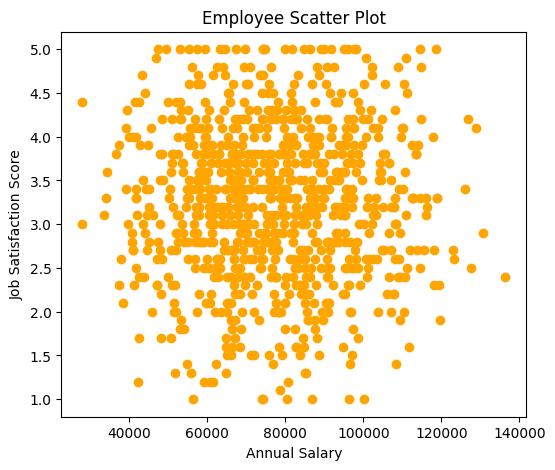

In [24]:
# Visualize the original data points by plotting Annual Salary against Job Satisfaction Score
plt.figure(figsize=(6,5))
plt.scatter(
    X['Annual_Salary'],
    X['Job_Satisfaction_Score'],
    color='orange'
)
plt.xlabel('Annual Salary')
plt.ylabel('Job Satisfaction Score')
plt.title('Employee Scatter Plot')
plt.show()

In [15]:
# Apply StandardScaler to normalize the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling complete using StandardScaler")

Feature scaling complete using StandardScaler


In [16]:
# Initialize the K-Means algorithm with 5 clusters and train it on the scaled feat
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
print("Model trained successfully")

Model trained successfully


In [18]:
# Assign cluster labels to the original dataset and display the first 5 rows with
labels = kmeans.labels_
data['Cluster'] = labels
data[['Annual_Salary', 'Job_Satisfaction_Score', 'Cluster']].head()

,Annual_Salary,Job_Satisfaction_Score,Cluster
0,57321,2.0,2
1,51606,1.3,2
2,102190,4.8,1
3,71178,3.8,3
4,77618,2.4,2


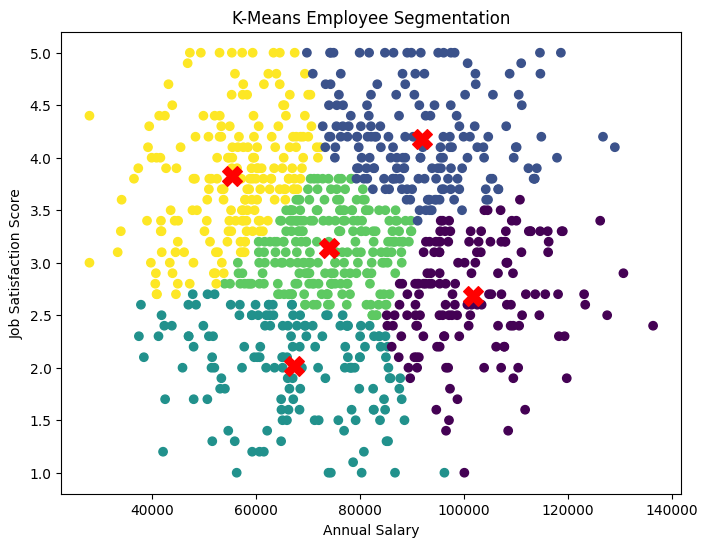

In [20]:
# Visualize the clusters by plotting Annual Salary against Job Satisfaction Score, with colors
plt.figure(figsize=(8,6))
plt.scatter(
    X['Annual_Salary'],
    X['Job_Satisfaction_Score'],
    c=labels,
    cmap='viridis'
)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    s=200,
    marker='X'
)
plt.xlabel("Annual Salary")
plt.ylabel("Job Satisfaction Score")
plt.title("K-Means Employee Segmentation")
plt.show()

In [21]:
# Calculate and display model evaluation metrics: Silhouette Score, WCSS (Inertia), and Davies-Bouldin Index
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

wcss = kmeans.inertia_
print("WCSS (Inertia):", wcss)
db_score = davies_bouldin_score(X_scaled, labels)
print("Davies-Bouldin Index:", db_score)

Silhouette Score: 0.31159176662054827
WCSS (Inertia): 515.6124486765029
Davies-Bouldin Index: 0.9337860925507273
